In [1]:
from pathlib import Path
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    log_loss,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})


In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
DATA_URLS = [
    "https://raw.githubusercontent.com/Giskard-AI/examples/main/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

if not DATA_PATH.exists():
    for url in DATA_URLS:
        try:
            urllib.request.urlretrieve(url, DATA_PATH)
            break
        except Exception:
            pass

raw_df = pd.read_csv(DATA_PATH)
raw_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", raw_df.shape)
raw_df.info()


Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

The dataset contains 21 columns and 7043 entries. Here's a summary of the features:

**Numerical Features (int64, float64):**
- `SeniorCitizen`: Indicates if the customer is a senior citizen (0 or 1).
- `tenure`: Number of months the customer has stayed with the company.
- `MonthlyCharges`: The amount charged to the customer monthly.
- `TotalCharges`: The total amount charged to the customer.

**Categorical Features (object):**
- `customerID`: A unique identifier for each customer.
- `gender`: Customer's gender (Male, Female).
- `Partner`: Whether the customer has a partner (Yes, No).
- `Dependents`: Whether the customer has dependents (Yes, No).
- `PhoneService`: Whether the customer has phone service (Yes, No).
- `MultipleLines`: Whether the customer has multiple lines (Yes, No, No phone service).
- `InternetService`: Customer's internet service provider (DSL, Fiber optic, No).
- `OnlineSecurity`: Whether the customer has online security (Yes, No, No internet service).
- `OnlineBackup`: Whether the customer has online backup (Yes, No, No internet service).
- `DeviceProtection`: Whether the customer has device protection (Yes, No, No internet service).
- `TechSupport`: Whether the customer has tech support (Yes, No, No internet service).
- `StreamingTV`: Whether the customer has streaming TV (Yes, No, No internet service).
- `StreamingMovies`: Whether the customer has streaming movies (Yes, No, No internet service).
- `Contract`: The customer's contract type (Month-to-month, One year, Two year).
- `PaperlessBilling`: Whether the customer has paperless billing (Yes, No).
- `PaymentMethod`: The customer's payment method.
- `Churn`: Whether the customer churned (Yes, No) - this is the target variable.

In [6]:
df = raw_df.copy()
df ["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df.drop(columns=["customerID"], inplace=True, errors="ignore")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
df.drop(columns=["Churn"], inplace=True)

In [8]:
df.shape

(7032, 20)

In [9]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ChurnFlag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [10]:
np.sum(df['ChurnFlag'] == 1), np.sum(df['ChurnFlag'] == 0)

(np.int64(1869), np.int64(5163))

In [12]:
np.sum(df['ChurnFlag'] == 1) / 7032,np.sum(df['ChurnFlag'] == 0) / 7032

(np.float64(0.26578498293515357), np.float64(0.7342150170648464))

In [14]:
# find correlation on numerical features
df_numerical = df[["tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]]
df_numerical.corr()

,tenure,MonthlyCharges,TotalCharges,ChurnFlag
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
ChurnFlag,-0.354049,0.192858,-0.199484,1.000000


In [15]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    churn_by_group = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    display((churn_by_group * 100).round(1).rename("churn_rate_%"))


,churn_rate_%
Contract,
Month-to-month,42.7
One year,11.3
Two year,2.8


,churn_rate_%
InternetService,
Fiber optic,41.9
DSL,19.0
No,7.4


,churn_rate_%
PaymentMethod,
Electronic check,45.3
Mailed check,19.2
Bank transfer (automatic),16.7
Credit card (automatic),15.3


In [24]:
# train test split
X = df.drop(columns=["ChurnFlag"])
y = df["ChurnFlag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
y_train.mean(), y_test.mean()

(5274, 19) (1758, 19) (5274,) (1758,)


(np.float64(0.2664012135001896), np.float64(0.26393629124004553))

In [31]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

categorical_features.append("SeniorCitizen")
numeric_features.remove("SeniorCitizen")

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)



Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


In [33]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)


def make_preprocess():
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", make_one_hot_encoder(), categorical_features),
    ])

def make_lr(class_weight=None):
    return LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, class_weight=class_weight)


def make_pipeline(class_weight=None):
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", make_lr(class_weight=class_weight)),
    ])


In [34]:
baseline_model = make_pipeline()
baseline_model.fit(X_train, y_train)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

y_pred_05 = (y_proba >= 0.5).astype(int)

In [35]:
y_proba, y_pred_05

(array([0.00202007, 0.67111812, 0.0813714 , ..., 0.22202436, 0.01520941,
        0.0527694 ]),
 array([0, 1, 0, ..., 0, 0, 0]))

In [36]:
def evaluate_model(y_true, y_score, threshold=0.5, label="model"):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "method": label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "positive_rate": y_pred.mean(),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "log_loss": log_loss(y_true, y_score),
    }


def show_result(result):
    return pd.DataFrame([result]).round(3)


def show_confusion(y_true, y_score, threshold=0.5, title="Confusion matrix"):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"]).plot(
        cmap="Blues", values_format="d", colorbar=False
    )
    plt.title(title)
    plt.show()


In [38]:
results = []
probabilities = {}

baseline_result = evaluate_model(y_test, y_proba, label="baseline")
results.append(baseline_result)
probabilities["Baseline LR"] = y_proba
show_result(baseline_result)

,method,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate,tn,fp,fn,tp,log_loss
0,baseline,0.5,0.801,0.649,0.539,0.589,0.85,0.656,0.219,1159,135,214,250,0.41


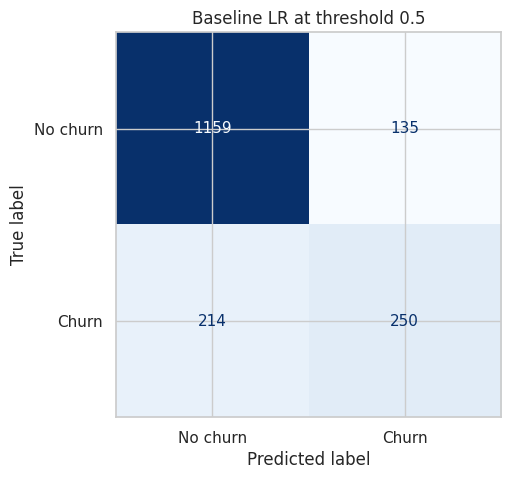

              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1294
       Churn       0.65      0.54      0.59       464

    accuracy                           0.80      1758
   macro avg       0.75      0.72      0.73      1758
weighted avg       0.79      0.80      0.80      1758



In [39]:
show_confusion(y_test, y_proba, threshold=0.5, title="Baseline LR at threshold 0.5")
print(classification_report(y_test, y_pred_05, target_names=["No churn", "Churn"]))


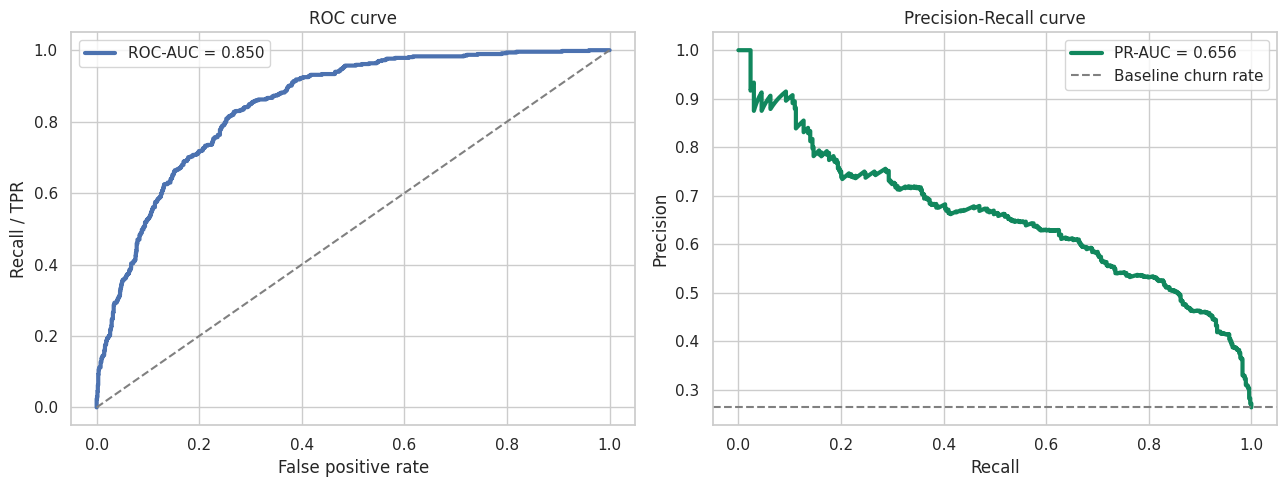

In [40]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, linewidth=3, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("Recall / TPR")
axes[0].legend()

axes[1].plot(recall, precision, linewidth=3, color="#11875d", label=f"PR-AUC = {average_precision_score(y_test, y_proba):.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Baseline churn rate")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


In [41]:
thresholds = np.arange(0.05, 0.96, 0.05)
threshold_df = pd.DataFrame([
    evaluate_model(y_test, y_proba, threshold=t, label="Baseline LR")
    for t in thresholds
])

threshold_df[["threshold", "precision", "recall", "f1", "positive_rate", "fp", "fn", "tp"]].round(3)


,threshold,precision,recall,f1,positive_rate,fp,fn,tp
0,0.05,0.358,0.983,0.525,0.724,816,8,456
1,0.10,0.406,0.957,0.570,0.622,650,20,444
2,0.15,0.440,0.931,0.598,0.559,550,32,432
3,0.20,0.469,0.877,0.612,0.493,460,57,407
4,0.25,0.512,0.838,0.636,0.432,371,75,389
5,0.30,0.536,0.778,0.635,0.383,312,103,361
6,0.35,0.555,0.724,0.629,0.344,269,128,336
7,0.40,0.593,0.679,0.633,0.302,216,149,315
8,0.45,0.629,0.621,0.625,0.261,170,176,288
9,0.50,0.649,0.539,0.589,0.219,135,214,250


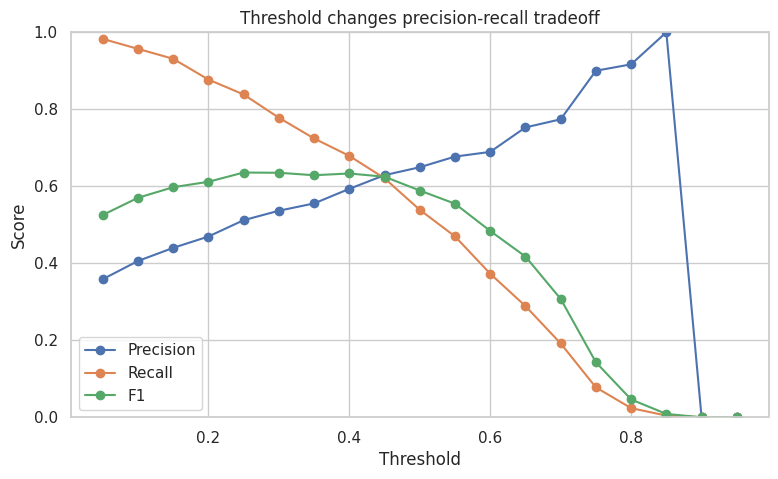

In [57]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold changes precision-recall tradeoff")
plt.ylim(0, 1)
plt.legend()
plt.show()


In [42]:
# Example policy: choose threshold with recall at least 70%, then maximize precision.
required_recall = 0.70
candidates = threshold_df[threshold_df["recall"] >= required_recall]

if len(candidates):
    tuned_threshold = candidates.sort_values("precision", ascending=False).iloc[0]["threshold"]
else:
    tuned_threshold = 0.5

tuned_result = evaluate_model(y_test, y_proba, threshold=tuned_threshold, label=f"Baseline tuned threshold ({tuned_threshold:.2f})")
results.append(tuned_result)

show_result(tuned_result)


,method,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate,tn,fp,fn,tp,log_loss
0,Baseline tuned threshold (0.35),0.35,0.774,0.555,0.724,0.629,0.85,0.656,0.344,1025,269,128,336,0.41


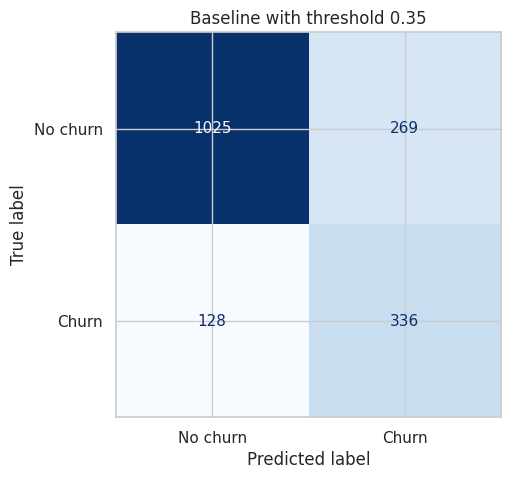

In [43]:
show_confusion(y_test, y_proba, threshold=tuned_threshold, title=f"Baseline with threshold {tuned_threshold:.2f}")

In [44]:

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [46]:
def make_imb_pipeline(sampler_steps):
    return ImbPipeline([
        ("preprocess", make_preprocess()),
        *sampler_steps,
        ("model", make_lr()),
    ])


def fit_report_store(label, model, threshold=0.5):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    result = evaluate_model(y_test, proba, threshold=threshold, label=label)
    results.append(result)
    probabilities[label] = proba
    display(show_result(result))
    show_confusion(y_test, proba, threshold=threshold, title=f"{label} at threshold {threshold}")
    return model, proba

def class_counts(y_values, label):
    counts = pd.Series(y_values).value_counts().sort_index()
    return pd.DataFrame([{
        "dataset": label,
        "no_churn": counts.get(0, 0),
        "churn": counts.get(1, 0),
        "churn_rate": counts.get(1, 0) / counts.sum(),
        "total": counts.sum(),
    }])

X_train_encoded = make_preprocess().fit_transform(X_train, y_train)
class_counts(y_train, "train")

,dataset,no_churn,churn,churn_rate,total
0,train,3869,1405,0.266401,5274


,method,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate,tn,fp,fn,tp,log_loss
0,Class weight balanced,0.5,0.753,0.52,0.823,0.637,0.849,0.653,0.418,941,353,82,382,0.487


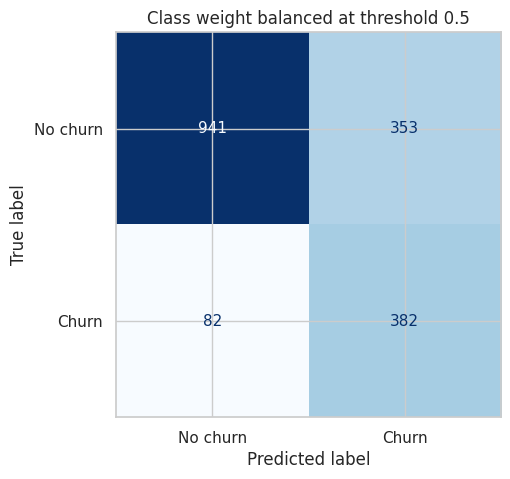

In [56]:
class_weight_model = make_pipeline(class_weight="balanced")
class_weight_model, class_weight_proba = fit_report_store(
    "Class weight balanced",
    class_weight_model,
    threshold=0.5,
)


In [48]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
_, y_ros = ros.fit_resample(X_train_encoded, y_train)

pd.concat([
    class_counts(y_train, "Original training data"),
    class_counts(y_ros, "After random oversampling"),
], ignore_index=True)


,dataset,no_churn,churn,churn_rate,total
0,Original training data,3869,1405,0.266401,5274
1,After random oversampling,3869,3869,0.500000,7738


,method,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate,tn,fp,fn,tp,log_loss
0,Random oversampling,0.5,0.755,0.524,0.81,0.636,0.849,0.651,0.408,952,342,88,376,0.486


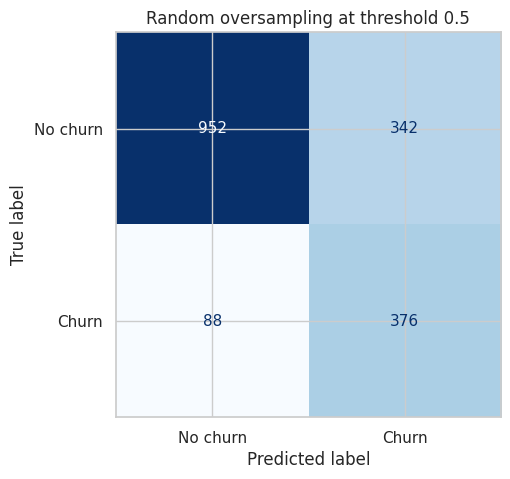

In [49]:
oversampling_model, oversampling_proba = fit_report_store(
    "Random oversampling",
    make_imb_pipeline([("sampler", RandomOverSampler(random_state=RANDOM_STATE))]),
    threshold=0.5,
)


In [50]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
_, y_rus = rus.fit_resample(X_train_encoded, y_train)

pd.concat([
    class_counts(y_train, "Original training data"),
    class_counts(y_rus, "After random undersampling"),
], ignore_index=True)


,dataset,no_churn,churn,churn_rate,total
0,Original training data,3869,1405,0.266401,5274
1,After random undersampling,1405,1405,0.500000,2810


,method,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate,tn,fp,fn,tp,log_loss
0,Random undersampling,0.5,0.749,0.516,0.819,0.633,0.848,0.65,0.419,937,357,84,380,0.489


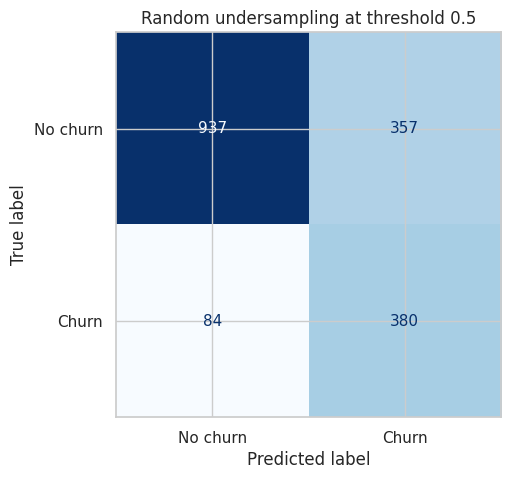

In [51]:
undersampling_model, undersampling_proba = fit_report_store(
    "Random undersampling",
    make_imb_pipeline([("sampler", RandomUnderSampler(random_state=RANDOM_STATE))]),
    threshold=0.5,
)


In [52]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
_, y_smote = smote.fit_resample(X_train_encoded, y_train)

pd.concat([
    class_counts(y_train, "Original training data"),
    class_counts(y_smote, "After SMOTE"),
], ignore_index=True)


,dataset,no_churn,churn,churn_rate,total
0,Original training data,3869,1405,0.266401,5274
1,After SMOTE,3869,3869,0.500000,7738


,method,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_rate,tn,fp,fn,tp,log_loss
0,SMOTE,0.5,0.756,0.524,0.808,0.636,0.851,0.651,0.407,954,340,89,375,0.478


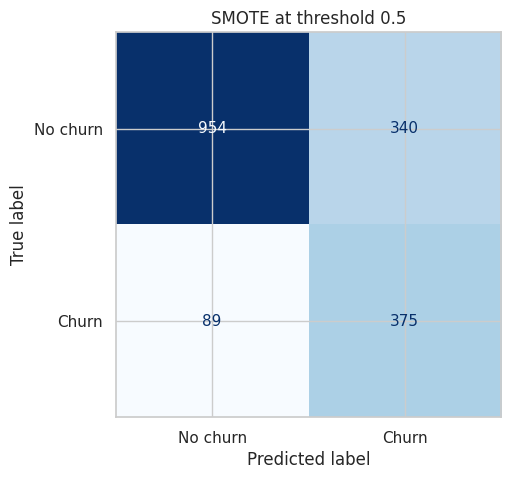

In [53]:
smote_model, smote_proba = fit_report_store(
    "SMOTE",
    make_imb_pipeline([("sampler", SMOTE(random_state=RANDOM_STATE, k_neighbors=5))]),
    threshold=0.5,
)


In [69]:
mask1 = X_test['PaymentMethod'] == 'Credit card (automatic)'
mask2 = X_test['SeniorCitizen'] == 1
# X_test[mask1 & mask2].shape

# y_test for this X_test
y_test[mask1 & mask2].shape
X_test_masks = X_test[mask1 & mask2]
y_test_masks = y_test[mask1 & mask2]

In [72]:
y_test_masks.mean()

np.float64(0.24561403508771928)